In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score



In [105]:
# Load dataset
# df = pd.read_csv("data_jantung.csv", sep=';')
df = pd.read_csv("heart_disease_data.csv")

In [106]:
y = (df['num'] > 0).astype(int)
X = df.drop('num', axis=1)

In [107]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [108]:
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  
0  0.0   6.0    0  
1  3.0   3.0    2  
2  2.0   7.0    1  
3  0.0   3.0    0  
4  0.0   3.0    0  


In [109]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [110]:
# Model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [99]:
# Prediksi
y_pred = dt_model.predict(X_test)

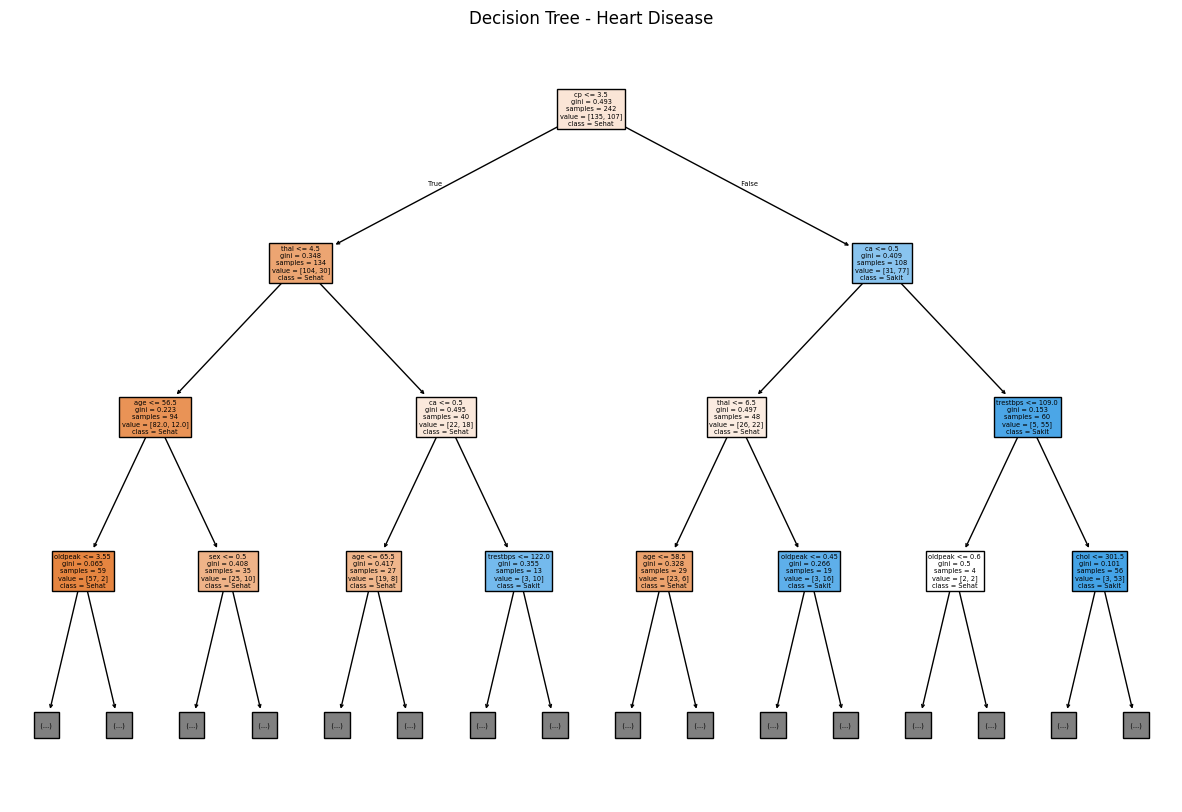

In [100]:
plt.figure(figsize=(15,10))
plot_tree(dt_model, max_depth=3, filled=True, feature_names=X.columns, class_names=["Sehat","Sakit"])
plt.title("Decision Tree - Heart Disease")
plt.show()

In [ ]:
# Evaluasi
print("Akurasi:", accuracy_score(y_test, y_pred))
print("Presisi :", precision_score(y_test, y_pred))
print("Recall  :", recall_score(y_test, y_pred))

Akurasi: 0.7377049180327869
Presisi : 0.75
Recall  : 0.75


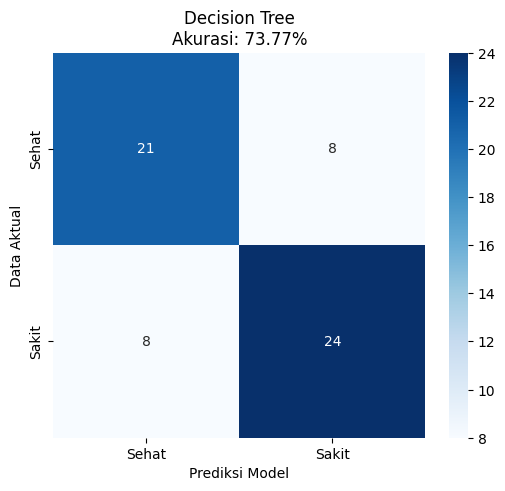

In [113]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Sehat","Sakit"],
            yticklabels=["Sehat","Sakit"])

plt.xlabel("Prediksi Model")
plt.ylabel("Data Aktual")
plt.title("Decision Tree\nAkurasi: {:.2f}%".format(accuracy_score(y_test, y_pred)*100))

plt.show()